# Olist SQL Analysis

SQL analysis using DuckDB directly on raw CSV files.

## Data Schema

![Olist Schema](../images/ERD.png)

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

duckdb.sql("CREATE OR REPLACE VIEW orders AS SELECT * FROM '../data/raw/olist_orders_dataset.csv'")
duckdb.sql("CREATE OR REPLACE VIEW order_items AS SELECT * FROM '../data/raw/olist_order_items_dataset.csv'")
duckdb.sql("CREATE OR REPLACE VIEW payments AS SELECT * FROM '../data/raw/olist_order_payments_dataset.csv'")
duckdb.sql("CREATE OR REPLACE VIEW products AS SELECT * FROM '../data/raw/olist_products_dataset.csv'")
duckdb.sql("CREATE OR REPLACE VIEW customers AS SELECT * FROM '../data/raw/olist_customers_dataset.csv'")
duckdb.sql("CREATE OR REPLACE VIEW sellers AS SELECT * FROM '../data/raw/olist_sellers_dataset.csv'")
duckdb.sql("CREATE OR REPLACE VIEW translations AS SELECT * FROM '../data/raw/product_category_name_translation.csv'")
duckdb.sql("CREATE OR REPLACE VIEW reviews AS SELECT * FROM '../data/raw/olist_order_reviews_dataset.csv'")

In [2]:
for name in ['orders', 'order_items', 'payments', 'products', 'customers', 'sellers', 'translations', 'reviews']:
    print(name)
    display(duckdb.sql(f"SELECT * FROM {name} LIMIT 2").df())

orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13


order_items


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93


payments


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP


translations


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories


reviews


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,None,None,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,None,None,2018-03-10,2018-03-11 03:05:13


In [3]:
duckdb.sql("""
    CREATE OR REPLACE VIEW order_base AS
    SELECT
        o.order_id,
        c.customer_unique_id,
        c.customer_state,
        o.order_purchase_timestamp AS purchased_at,
        o.order_delivered_customer_date AS delivered_at,
        o.order_estimated_delivery_date + INTERVAL 1 DAY AS promised_at,
        date_diff('second', o.order_purchase_timestamp, o.order_delivered_customer_date) / 86400.0 AS delivery_days,
        (o.order_delivered_customer_date > o.order_estimated_delivery_date + INTERVAL 1 DAY)::INT AS is_late
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
""")

## 1. Data Quality

Checking for duplicates, missing values, and data integrity issues
before analysis.

### Q1: Duplicate order_id check

In [4]:
duckdb.sql("""
    WITH t AS(
    SELECT order_id, order_purchase_timestamp,
        ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY order_purchase_timestamp) AS rnk
    FROM orders
    )

    SELECT order_id, order_purchase_timestamp
    FROM t
    WHERE rnk > 1
""").df()

,order_id,order_purchase_timestamp


No duplicates found.

### Q2: Order status distribution

In [5]:
duckdb.sql("""
    SELECT order_status,
       COUNT(*) AS orders,
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM orders
        GROUP BY order_status
    ORDER BY orders DESC
""").df()

,order_status,orders,pct
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


96,478 out of 99,441 orders delivered (97%).

### Q3: Missing delivery dates in delivered orders

In [6]:
duckdb.sql("""
    SELECT
        COUNT(*) AS delivered_status,
        COUNT(*) FILTER (WHERE order_delivered_customer_date IS NULL) AS no_delivery_date,
        COUNT(*) FILTER (WHERE order_delivered_customer_date IS NOT NULL) AS usable
    FROM orders
    WHERE order_status = 'delivered'
""").df()

,delivered_status,no_delivery_date,usable
0,96478,8,96470


8 orders carry status delivered with no delivery date.
`order_base` drops them: 96,478 to 96,470.

### Q4: Impossible dates (delivery before purchase)

In [7]:
duckdb.sql("""
    SELECT COUNT(*) AS total_wrong_dates
    FROM orders
    WHERE order_delivered_customer_date < order_purchase_timestamp
""").df()

,total_wrong_dates
0,0


0 orders found.

### Q5: Order vs order-item grain
Joining `order_items` multiplies rows. An order with three items becomes three.

In [8]:
duckdb.sql("""
    SELECT
        COUNT(DISTINCT ob.order_id) AS orders,
        COUNT(*) AS order_item_rows,
        COUNT(DISTINCT ob.order_id) FILTER (WHERE ob.is_late = 1) AS late_orders,
        COUNT(*) FILTER (WHERE ob.is_late = 1) AS late_order_item_rows
    FROM order_base ob
    JOIN order_items oi ON ob.order_id = oi.order_id
""").df()

,orders,order_item_rows,late_orders,late_order_item_rows
0,96470,110189,6534,7264


Late count is 6,534 by order and 7,264 by item row.

## 2. Commercial Analysis (payments + items + products)

### Q6: Monthly revenue and MoM growth

In [9]:
duckdb.sql("""
    WITH monthly AS (
        SELECT DATE_TRUNC('month', o.order_purchase_timestamp) AS month,
               SUM(oi.price) AS revenue
        FROM orders o
        JOIN order_items oi ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
          AND o.order_purchase_timestamp >= DATE '2017-01-01'
        GROUP BY 1
    ),
    with_lag AS (
        SELECT month, revenue,
               LAG(revenue) OVER (ORDER BY month) AS prev_revenue
        FROM monthly
    )

    SELECT month,
           ROUND(revenue, 2) AS revenue,
           ROUND(prev_revenue, 2) AS prev_revenue,
           ROUND((revenue - prev_revenue) * 100.0 / prev_revenue, 2) AS mom_pct
    FROM with_lag
    ORDER BY month
""").df()

,month,revenue,prev_revenue,mom_pct
0,2017-01-01,111798.36,NaN,NaN
1,2017-02-01,234223.40,111798.36,109.51
2,2017-03-01,359198.85,234223.40,53.36
3,2017-04-01,340669.68,359198.85,-5.16
4,2017-05-01,489338.25,340669.68,43.64
5,2017-06-01,421923.37,489338.25,-13.78
6,2017-07-01,481604.52,421923.37,14.15
7,2017-08-01,554699.70,481604.52,15.18
8,2017-09-01,607399.67,554699.70,9.50
9,2017-10-01,648247.65,607399.67,6.73


December 2016 has almost no revenue, so the series starts at 2017-01.

Revenue is the sum of item prices. Freight goes to the carrier and the payments table has
several rows per order.

### Q7: Top 10 categories by revenue

In [10]:
duckdb.sql("""
    SELECT t.product_category_name_english AS category,
       ROUND(SUM(oi.price), 2) AS revenue
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN products p ON oi.product_id = p.product_id
    JOIN translations t ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
    GROUP BY 1
    ORDER BY revenue DESC
    LIMIT 10
""").df()

,category,revenue
0,health_beauty,1233131.72
1,watches_gifts,1166176.98
2,bed_bath_table,1023434.76
3,sports_leisure,954852.55
4,computers_accessories,888724.61
5,furniture_decor,711927.69
6,housewares,615628.69
7,cool_stuff,610204.10
8,auto,578966.65
9,toys,471286.48


Health & beauty leads with 1.23M, followed by watches and bed/bath.

### Q8: Payment method distribution

In [11]:
duckdb.sql("""
    SELECT payment_type, COUNT(*) AS total, ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS perc
    FROM payments
    GROUP BY payment_type
    ORDER BY total DESC
""").df()

,payment_type,total,perc
0,credit_card,76795,73.92
1,boleto,19784,19.04
2,voucher,5775,5.56
3,debit_card,1529,1.47
4,not_defined,3,0.00


Credit card dominates at 73.9%. Boleto is second at 19%.

### Q9: Average order value by state

In [12]:
duckdb.sql("""
    WITH order_totals AS (
        SELECT order_id,
               SUM(price) AS goods,
               SUM(freight_value) AS freight
        FROM order_items
        GROUP BY order_id
    )

    SELECT c.customer_state,
           COUNT(*) AS orders,
           ROUND(AVG(ot.goods), 2) AS avg_goods,
           ROUND(AVG(ot.freight), 2) AS avg_freight,
           ROUND(AVG(ot.freight) * 100.0 / AVG(ot.goods + ot.freight), 1) AS freight_pct
    FROM orders o
    JOIN order_totals ot ON o.order_id = ot.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
    ORDER BY avg_goods DESC
""").df()

,customer_state,orders,avg_goods,avg_freight,freight_pct
0,PB,517,217.77,48.84,18.3
1,AP,67,199.62,41.30,17.1
2,AC,80,199.14,45.55,18.6
3,AL,397,198.63,38.58,16.3
4,RO,243,187.99,46.43,19.8
5,PA,946,184.43,39.70,17.7
6,PI,476,177.99,42.98,19.5
7,TO,274,176.65,42.35,19.3
8,RN,474,173.22,39.26,18.5
9,RR,41,172.13,48.34,21.9


Goods average 217.77 in PB against 125.12 in SP, freight 48.84 against 17.33. Remote states
buy more expensive goods, so the AOV gap is not just shipping inside the total.

### Q10: Pareto, seller revenue concentration

In [13]:
duckdb.sql("""
    WITH seller_revenue AS (
        SELECT seller_id, SUM(price) AS revenue
        FROM order_items
        GROUP BY seller_id
    ), com AS (
        SELECT seller_id,
               SUM(revenue) OVER (ORDER BY revenue DESC
                                  ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
               / SUM(revenue) OVER () AS cum_share
        FROM seller_revenue
    )

    SELECT COUNT(*) AS sellers_to_80pct,
           (SELECT COUNT(*) FROM seller_revenue) AS total_sellers,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM seller_revenue), 1) AS pct_of_sellers
    FROM com
    WHERE cum_share <= 0.8
""").df()

,sellers_to_80pct,total_sellers,pct_of_sellers
0,543,3095,17.5


543 of 3,095 sellers, 17.5%, generate 80% of revenue.

## 3. Delivery & Reviews

Key findings from Python notebooks reproduced in SQL.

### Q11: On-time delivery rate

In [14]:
duckdb.sql("""
    SELECT
        COUNT(*) AS orders,
        ROUND(AVG(1 - is_late) * 100, 2) AS on_time_pct
    FROM order_base
""").df()

,orders,on_time_pct
0,96470,93.23


93.23% of delivered orders arrive by the end of the promised day.
Matches notebook 01. The promised date is stored at 00:00, so it is read as end of day.

### Q12: Review score by delivery status

In [15]:
duckdb.sql("""
    WITH last_review AS (
        SELECT order_id, review_score,
               ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY review_creation_date DESC) AS rnk
        FROM reviews
    )

    SELECT
        CASE WHEN ob.is_late = 1 THEN 'late' ELSE 'on-time' END AS delivery_status,
        COUNT(*) AS orders,
        ROUND(AVG(r.review_score), 2) AS avg_score
    FROM order_base ob
    JOIN last_review r ON ob.order_id = r.order_id AND r.rnk = 1
    GROUP BY 1
    ORDER BY avg_score
""").df()

,delivery_status,orders,avg_score
0,late,6381,2.27
1,on-time,89443,4.29


Late orders average 2.27 stars, on-time 4.29.
The 6,381 late orders here match notebook 02 exactly. The 646 orders with no review drop out on the join.
Some orders carry more than one review, so the latest one is kept.

### Q13: Late delivery concentration by seller

In [16]:
duckdb.sql("""
    WITH order_seller AS (
        SELECT DISTINCT ob.order_id, oi.seller_id, ob.is_late, ob.customer_state
        FROM order_base ob
        JOIN order_items oi ON ob.order_id = oi.order_id
    ),
    state_rate AS (
        SELECT customer_state, AVG(is_late) AS expected_rate
        FROM order_base
        GROUP BY 1
    ),
    seller_stats AS (
        SELECT os.seller_id,
               COUNT(*) AS orders,
               SUM(os.is_late) AS late_orders,
               SUM(sr.expected_rate) AS expected_late,
               SUM(os.is_late) - SUM(sr.expected_rate) AS excess_late,
               SUM(os.is_late) / SUM(sr.expected_rate) AS lift
        FROM order_seller os
        JOIN state_rate sr ON os.customer_state = sr.customer_state
        GROUP BY 1
        HAVING COUNT(*) >= 50
    )
    SELECT COUNT(*) AS flagged_sellers,
           ROUND(SUM(excess_late), 1) AS excess_late,
           ROUND(SUM(excess_late) * 100.0 / (SELECT SUM(is_late) FROM order_base), 2) AS pct_of_late,
           SUM(orders) AS their_orders
    FROM seller_stats
    WHERE lift >= 1.5 AND excess_late >= 10
""").df()

,flagged_sellers,excess_late,pct_of_late,their_orders
0,17,295.3,4.52,3976.0


17 sellers carry 295 excess late orders, 4.5% of the total, once each is measured against
their own routes. Ranking by raw volume instead gives 50 sellers and 38%, which measures
seller size.

### Q14: Repeat buyers

In [17]:
duckdb.sql("""
    SELECT
        COUNT(*) AS customers,
        COUNT(*) FILTER (WHERE orders > 1) AS repeat_buyers,
        ROUND(COUNT(*) FILTER (WHERE orders > 1) * 100.0 / COUNT(*), 2) AS pct
    FROM (
        SELECT c.customer_unique_id, COUNT(*) AS orders
        FROM customers c
        JOIN orders o ON c.customer_id = o.customer_id
        GROUP BY c.customer_unique_id
    )
""").df()

,customers,repeat_buyers,pct
0,96096,2997,3.12


2,997 of 96,096 customers placed more than one order, 3.12%.

## 4. Cohorts and Retention

This section tracks where those customers come from.

### Q15: Cohort activity by month

In [18]:
cohorts = duckdb.sql("""
    WITH first_order AS (
        SELECT customer_unique_id, MIN(purchased_at) AS first_purchase
        FROM order_base
        GROUP BY customer_unique_id
    ), activity AS (
        SELECT ob.customer_unique_id,
               DATE_TRUNC('month', f.first_purchase) AS cohort_month,
               date_diff('month', DATE_TRUNC('month', f.first_purchase), DATE_TRUNC('month', ob.purchased_at)) AS month_index
        FROM order_base ob
        JOIN first_order f ON ob.customer_unique_id = f.customer_unique_id
    )
    SELECT cohort_month, month_index, COUNT(DISTINCT customer_unique_id) AS customers
    FROM activity
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

In [19]:
matrix = (cohorts
          .pivot(index='cohort_month', columns='month_index', values='customers')
          .fillna(0)
          .astype(int))
matrix.index = matrix.index.astype(str).str[:7]
matrix.iloc[:, :8]

month_index,0,1,2,3,4,5,6,7
cohort_month,,,,,,,,
2016-09,1,0,0,0,0,0,0,0
2016-10,262,0,0,0,0,0,1,0
2016-12,1,1,0,0,0,0,0,0
2017-01,717,2,2,1,3,1,3,1
2017-02,1628,3,5,2,7,2,4,3
2017-03,2503,11,9,10,9,4,4,8
2017-04,2256,14,5,4,6,6,8,7
2017-05,3450,16,16,10,10,11,14,5
2017-06,3037,15,12,13,9,12,11,7


The same numbers pivoted into a cohort matrix.

### Q16: Monthly retention by cohort

In [20]:
retention = matrix.div(matrix[0], axis=0).mul(100).round(2)
retention.loc['2017-01':].iloc[:, :8]

month_index,0,1,2,3,4,5,6,7
cohort_month,,,,,,,,
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18
2017-03,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32
2017-04,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31
2017-05,100.0,0.46,0.46,0.29,0.29,0.32,0.41,0.14
2017-06,100.0,0.49,0.40,0.43,0.30,0.40,0.36,0.23
2017-07,100.0,0.53,0.35,0.24,0.29,0.21,0.32,0.11
2017-08,100.0,0.69,0.35,0.27,0.35,0.52,0.30,0.27
2017-09,100.0,0.70,0.55,0.27,0.45,0.22,0.22,0.25


Month 1 retention stays between 0.2% and 0.7% across 18 cohorts with no trend. The curve does
not decay, it starts near zero.

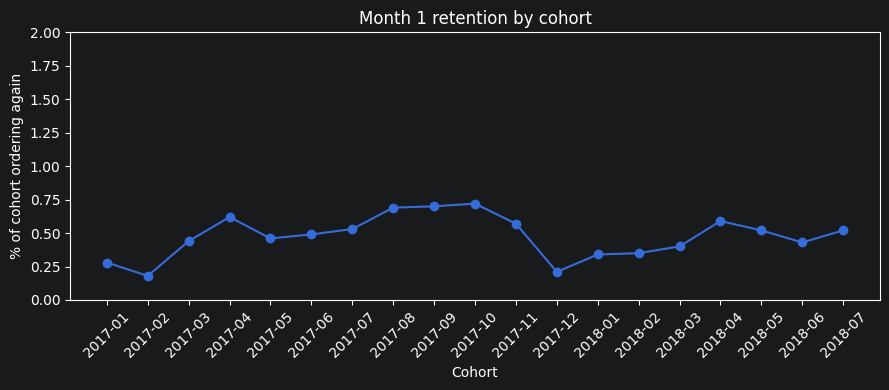

In [21]:
m1 = retention.loc['2017-01':'2018-07', 1]

plt.figure(figsize=(9, 4))
plt.plot(m1.index, m1.values, marker='o')
plt.ylim(0, 2)
plt.ylabel('% of cohort ordering again')
plt.xlabel('Cohort')
plt.title('Month 1 retention by cohort')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/month1_retention.png', dpi=150)
plt.show()

### Q17: Time to second order

In [22]:
duckdb.sql("""
    WITH t AS (
        SELECT customer_unique_id, purchased_at, order_id,
            ROW_NUMBER() OVER (PARTITION BY customer_unique_id ORDER BY purchased_at, order_id) AS rnk,
            LEAD(purchased_at) OVER (PARTITION BY customer_unique_id ORDER BY purchased_at, order_id) AS second_order
        FROM order_base
    ), gaps AS (
        SELECT second_order::date - purchased_at::date AS days
        FROM t
        WHERE rnk = 1 AND second_order IS NOT NULL
    )
    SELECT
        CASE
            WHEN days <= 7 THEN '0-7'
            WHEN days <= 30 THEN '8-30'
            WHEN days <= 90 THEN '31-90'
            WHEN days <= 180 THEN '91-180'
            ELSE '180+'
        END AS bucket,
        COUNT(*) AS customers,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM gaps
    GROUP BY 1
    ORDER BY MIN(days)
""").df()

,bucket,customers,pct
0,0-7,1028,36.70
1,8-30,388,13.85
2,31-90,492,17.57
3,91-180,413,14.74
4,180+,480,17.14


Of 2,801 returning customers, 36.7% order again within a week.
Most of that first bucket is probably one cart split into several orders, not a real second purchase.
The rest is spread evenly, and 17.1% come back after six months or more.

In [23]:
duckdb.sql("""
    WITH t AS (
        SELECT customer_unique_id, purchased_at, order_id,
            ROW_NUMBER() OVER (PARTITION BY customer_unique_id ORDER BY purchased_at, order_id) AS rnk,
            LEAD(purchased_at) OVER (PARTITION BY customer_unique_id ORDER BY purchased_at, order_id) AS second_order
        FROM order_base
    ), gaps AS (
        SELECT second_order::date - purchased_at::date AS days
        FROM t
        WHERE rnk = 1 AND second_order IS NOT NULL
    )
    SELECT COUNT(*) AS customers,
           ROUND(MEDIAN(days), 1) AS median_days,
           MIN(days) AS min_days,
           MAX(days) AS max_days
    FROM gaps
""").df()

,customers,median_days,min_days,max_days
0,2801,29.0,0,609


Median gap is 29 days, ranging from same day to 609.
Split carts in the first bucket pull the median down, so 29 days is not a typical gap between two real purchases.

### Q18: Repeat rate after a late first order

In [24]:
duckdb.sql("""
    WITH t AS(
        SELECT customer_unique_id, purchased_at, is_late,
            ROW_NUMBER() OVER (PARTITION BY customer_unique_id ORDER BY purchased_at, order_id) AS rnk,
            COUNT(*) OVER (PARTITION BY customer_unique_id) AS total_orders
        FROM order_base
    )

    SELECT is_late AS first_late, COUNT(*) AS customers,
        ROUND(SUM( CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS repeat_pct
    FROM t
    WHERE rnk = 1
    GROUP BY 1
""").df()

,first_late,customers,repeat_pct
0,0,86995,3.04
1,1,6355,2.52


On-time first order: 3.04% come back. Late first order: 2.52%, about 17% lower.
The late group has 6,355 customers and 160 returns against 193 expected. That is a signal,
not proof.

### Q19: Revenue lost to late first orders

In [25]:
duckdb.sql("""
    WITH order_value AS (
        SELECT order_id, SUM(price) AS value
        FROM order_items
        GROUP BY order_id
    ),
    t AS (
        SELECT ob.customer_unique_id, ob.is_late, ov.value,
               ROW_NUMBER() OVER (PARTITION BY ob.customer_unique_id ORDER BY ob.purchased_at, ob.order_id) AS rnk,
               COUNT(*) OVER (PARTITION BY ob.customer_unique_id) AS total_orders
        FROM order_base ob
        JOIN order_value ov ON ob.order_id = ov.order_id
    ),
    first_orders AS (
        SELECT is_late,
               COUNT(*) AS customers,
               SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS repeat_rate
        FROM t
        WHERE rnk = 1
        GROUP BY 1
    ),
    repeat_value AS (
        SELECT AVG(value) AS avg_repeat_order
        FROM t
        WHERE rnk > 1
    )
    SELECT
        l.customers AS late_first_customers,
        ROUND(o.repeat_rate * 100, 2) AS on_time_repeat_pct,
        ROUND(l.repeat_rate * 100, 2) AS late_repeat_pct,
        ROUND(l.customers * (o.repeat_rate - l.repeat_rate), 1) AS customers_lost,
        ROUND(rv.avg_repeat_order, 2) AS avg_repeat_order,
        ROUND(l.customers * (o.repeat_rate - l.repeat_rate) * rv.avg_repeat_order, 2) AS revenue_lost
    FROM first_orders l
    CROSS JOIN first_orders o
    CROSS JOIN repeat_value rv
    WHERE l.is_late = 1 AND o.is_late = 0
""").df()

,late_first_customers,on_time_repeat_pct,late_repeat_pct,customers_lost,avg_repeat_order,revenue_lost
0,6355,3.04,2.52,32.9,122.89,4046.24


Late first orders cost about 4,046 in lost repeat revenue over two years, roughly 0.03% of
platform revenue: 33 customers at an average second order of 123.

Retention is not a reason to fix delivery. At a 3% repeat rate there is nothing to retain.
The case sits in the review scores.

## Findings

1. 93.23% of orders arrive by the end of the promised day.
2. A late order averages 2.27 stars against 4.29 for an on-time one.
3. Sellers explain 4.5% of late deliveries once measured against their own routes.
4. 543 of 3,095 sellers generate 80% of revenue.
5. 3.12% of customers order twice, and month 1 retention stays under 0.7% in every cohort.
6. A late first order drops the repeat rate from 3.04% to 2.52%, worth about 4,046 over two
   years. Retention is not the argument for fixing delivery.